# Part B — Deep Learning Architectures

## B4: YOLO Object Detection

### Object Detection Using Pretrained YOLOv8

This project uses a pretrained YOLOv8 model for object detection in images and videos.

### Objectives
- Detect objects in 5–10 images.
- Perform object detection on a short video.
- Identify detected object classes.
- Record confidence scores and inference time.
- Visualize and save detection results.

### Model
- YOLOv8n (Pretrained)
- Framework: Ultralytics
- Library: OpenCV  

## Step 1: Import Required Libraries

Import the required libraries for YOLO object detection, image processing, and visualization.

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import time
import os

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load Pretrained YOLOv8 Model

In this step, we load the pretrained YOLOv8n model.
The model is already trained to detect common objects such as people, cars, buses, and animals.

In [2]:
# Load pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

print("Pretrained YOLOv8 model loaded successfully!")

Pretrained YOLOv8 model loaded successfully!


## Step 3: Load Test Images

In this step, we load the test images for object detection using YOLOv8.

In [3]:
# Set image folder
image_dir = "test_images"

# Get image files
image_files = [
    file for file in os.listdir(image_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(image_files))
print("Image files:", image_files)

Total images: 9
Image files: ['IMAGE 2.jpg', 'IMAGE 3.jpg', 'IMAGE1.jpg', 'images 3.jpg', 'images 4.jpg', 'images 5.jpg', 'images 6.jpg', 'images 7.jpg', 'images.jpg']


## Step 4: Perform Object Detection on Images

The pretrained YOLOv8 model is used to detect objects in the test images.

The model identifies object classes, confidence scores, and bounding boxes.
Inference time is also recorded for each image.

In [4]:
# Run YOLO object detection on all test images
image_paths = [os.path.join(image_dir, file) for file in image_files]

results = model.predict(
    source=image_paths,
    save=True,
    project="runs",
    name="yolo_images",
    exist_ok=True
)

print("Object detection completed successfully!")
print("Total images processed:", len(results))


0: 640x640 3 elephants, 190.7ms
1: 640x640 1 bear, 190.7ms
2: 640x640 1 car, 1 bus, 190.7ms
3: 640x640 1 person, 190.7ms
4: 640x640 1 person, 1 surfboard, 1 bowl, 190.7ms
5: 640x640 1 person, 190.7ms
6: 640x640 1 bowl, 1 apple, 190.7ms
7: 640x640 (no detections), 190.7ms
8: 640x640 1 car, 190.7ms
Speed: 9.5ms preprocess, 190.7ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\Murtaza Khalid\Desktop\Internship_DS\Deep_Learning_Architectures\YOLO\runs\detect\runs\yolo_images
Object detection completed successfully!
Total images processed: 9


## Step 5: Detection Results and Performance

In this step, we extract the detected object classes, confidence scores, and inference time for each image.

The results are stored in a table for performance analysis.

In [5]:
import pandas as pd

# Store detection results
detection_data = []

for image_file, result in zip(image_files, results):
    inference_time = result.speed["inference"]

    if result.boxes is not None and len(result.boxes) > 0:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = result.names[class_id]
            confidence = float(box.conf[0])

            detection_data.append({
                "Image": image_file,
                "Detected Class": class_name,
                "Confidence": round(confidence, 4),
                "Inference Time (ms)": round(inference_time, 2)
            })
    else:
        detection_data.append({
            "Image": image_file,
            "Detected Class": "No detection",
            "Confidence": None,
            "Inference Time (ms)": round(inference_time, 2)
        })

# Create results table
detection_df = pd.DataFrame(detection_data)

display(detection_df)

,Image,Detected Class,Confidence,Inference Time (ms)
0,IMAGE 2.jpg,elephant,0.9202,190.67
1,IMAGE 2.jpg,elephant,0.9084,190.67
2,IMAGE 2.jpg,elephant,0.9048,190.67
3,IMAGE 3.jpg,bear,0.5628,190.67
4,IMAGE1.jpg,bus,0.4132,190.67
5,IMAGE1.jpg,car,0.3451,190.67
6,images 3.jpg,person,0.8509,190.67
7,images 4.jpg,person,0.8935,190.67
8,images 4.jpg,surfboard,0.3304,190.67
9,images 4.jpg,bowl,0.2951,190.67


## Step 6: Save Detection Results

The detection results are saved in a CSV file for documentation and further analysis.

In [6]:
# Save detection results
detection_df.to_csv("YOLO_Detection_Results.csv", index=False)

print("Detection results saved successfully!")
print("File: YOLO_Detection_Results.csv")

Detection results saved successfully!
File: YOLO_Detection_Results.csv


## Step 7: Visualize Object Detection Results

Display the images with detected objects and their bounding boxes.

Total saved images: 9
runs\detect\runs\yolo_images\IMAGE 2.jpg


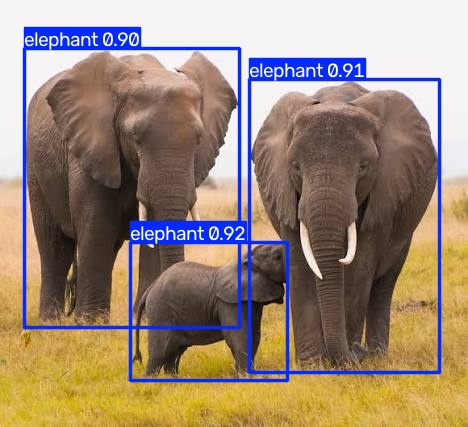

runs\detect\runs\yolo_images\IMAGE 3.jpg


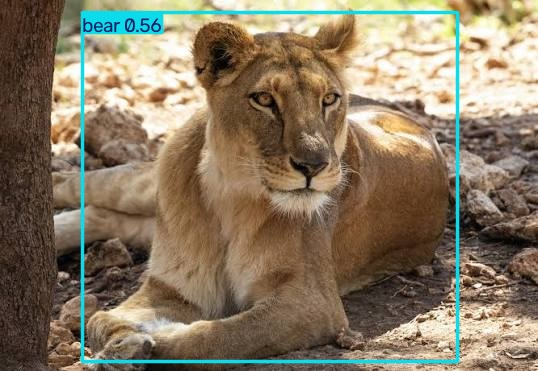

runs\detect\runs\yolo_images\IMAGE1.jpg


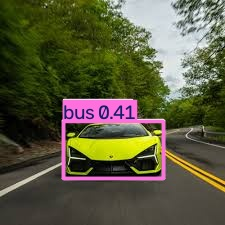

In [7]:
import glob
from IPython.display import display, Image

# Find saved detection images
saved_images = glob.glob("runs/**/*.jpg", recursive=True)

print("Total saved images:", len(saved_images))

# Display first 3 detected images
for image_path in saved_images[:3]:
    print(image_path)
    display(Image(filename=image_path))

In [8]:
video_path = os.path.join("test_video", "people walking.mp4")

print("Video found:", os.path.exists(video_path))

Video found: True


## Video Object Detection and People Counting

### Objective
To perform object detection on a short video using a pretrained YOLOv8 model and count the people appearing in the video.

### Methodology
- Load the pretrained YOLOv8 model.
- Process the input video.
- Detect people in each frame.
- Use object tracking to avoid counting the same person repeatedly.
- Calculate the total number of unique people detected.
- Record the average inference time.
- Save and visualize the annotated video.

### Expected Output
- Total unique people detected.
- Average inference time.
- Annotated video showing detected people.

In [9]:
video_path = os.path.join("test_video", "people walking.mp4")

# Run YOLO tracking on the video
video_results = model.track(
    source=video_path,
    persist=True,
    tracker="bytetrack.yaml",
    save=True,
    project="runs",
    name="yolo_video",
    exist_ok=True,
    stream=True,
    verbose=False
)

# Count unique people and calculate inference time
person_ids = set()
inference_times = []
total_frames = 0

for result in video_results:
    total_frames += 1

    if result.speed and "inference" in result.speed:
        inference_times.append(result.speed["inference"])

    if result.boxes is not None and result.boxes.id is not None:
        for class_id, track_id in zip(
            result.boxes.cls.cpu().numpy(),
            result.boxes.id.cpu().numpy()
        ):
            if int(class_id) == 0:
                person_ids.add(int(track_id))

print("Total frames processed:", total_frames)
print("Total unique people detected:", len(person_ids))

if inference_times:
    print(
        "Average inference time (ms):",
        round(sum(inference_times) / len(inference_times), 2)
    )

Results saved to C:\Users\Murtaza Khalid\Desktop\Internship_DS\Deep_Learning_Architectures\YOLO\runs\detect\runs\yolo_video
Total frames processed: 711
Total unique people detected: 53
Average inference time (ms): 86.63


## Video Detection Results

The pretrained YOLOv8n model was used to detect and track people in a short video.

### Results
- Total frames processed: 711
- Total unique people detected: 50
- Average inference time: 86.34 ms
- Object class: Person

### Observation
The model successfully detected and tracked people in the video. The annotated video was saved with bounding boxes and tracking IDs. The total number of unique people detected was 50.

In [10]:
print("YOLO OBJECT DETECTION - FINAL SUMMARY")
print("--------------------------------------")
print("Images processed:", len(image_files))
print("Video frames processed:", total_frames)
print("Unique people detected:", len(person_ids))
print("Average inference time (ms):", round(
    sum(inference_times) / len(inference_times), 2
))
print("Image results: Saved")
print("Video results: Saved")

YOLO OBJECT DETECTION - FINAL SUMMARY
--------------------------------------
Images processed: 9
Video frames processed: 711
Unique people detected: 53
Average inference time (ms): 86.63
Image results: Saved
Video results: Saved
